In [1]:
import proteosim as ps
proteins = ps.read_fasta("../proteosim/data/sample_proteins.fasta")
len(proteins)

3

In [2]:
import proteosim as ps
cleave_pattern = ps.enzyme_cleavage_patterns['LysC']
digested_proteins = ps.digest_protein_collection(proteins,cleave_pattern)
digested_proteins

{'P11802': ['MATSRYEPVAEIGVGAYGTVYK',
  'ARDPHSGHFVALK',
  'VTLVFEHVDQDLRTYLDK',
  'APPPGLPAETIK',
  'DLMRQFLRGLDFLHANCIVHRDLK',
  'PENILVTSGGTVK',
  'PLFCGNSEADQLGK',
  'RISAFRALQHSYLHK',
  'DEGNPE'],
 'A0A087WTH1': ['MEDEEK', 'AEERHK', 'AGRSEEAVRWGARARK'],
 'A0A087WTH5': ['MVIEWERPRMILSNTTAVTPFLTK',
  'LWQETVQQGGNMSGLARRSPRSGDGK',
  'LEALYVLMVLGFFGFFTLGIMLSYIRSK',
  'LEHSNDPFNVYIESNAWQEK']}

In [3]:
import proteosim as ps

pooled_peptides = []
for peptide_list in digested_proteins.values():
    pooled_peptides += peptide_list

predicted_RT = ps.predict_lc_retention_times(pooled_peptides)
predicted_RT

{'MATSRYEPVAEIGVGAYGTVYK': 51.6,
 'ARDPHSGHFVALK': 32.1,
 'VTLVFEHVDQDLRTYLDK': 52.1,
 'APPPGLPAETIK': 29.1,
 'DLMRQFLRGLDFLHANCIVHRDLK': 85.9,
 'PENILVTSGGTVK': 28.3,
 'PLFCGNSEADQLGK': 28.2,
 'RISAFRALQHSYLHK': 49.3,
 'DEGNPE': -4.0,
 'MEDEEK': -0.7,
 'AEERHK': 2.5,
 'AGRSEEAVRWGARARK': 23.9,
 'MVIEWERPRMILSNTTAVTPFLTK': 82.0,
 'LWQETVQQGGNMSGLARRSPRSGDGK': 39.2,
 'LEALYVLMVLGFFGFFTLGIMLSYIRSK': 139.5,
 'LEHSNDPFNVYIESNAWQEK': 42.6}

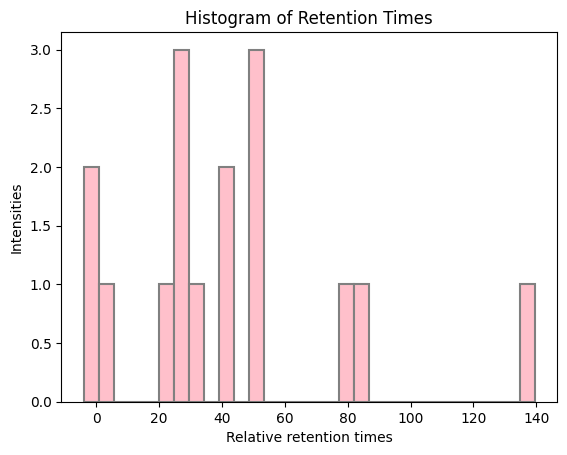

In [4]:
import proteosim as ps

ps.plot_retention_time(retention_times = list(predicted_RT.values()) , resolution=30)

In [5]:
import proteosim as ps

select_peps = ps.select_retention_time_window(
    peptide_rt_map = predicted_RT,
    lower_ret_time = 20,
    upper_ret_time = 40,
)

select_peps

{'ARDPHSGHFVALK': 32.1,
 'APPPGLPAETIK': 29.1,
 'PENILVTSGGTVK': 28.3,
 'PLFCGNSEADQLGK': 28.2,
 'AGRSEEAVRWGARARK': 23.9,
 'LWQETVQQGGNMSGLARRSPRSGDGK': 39.2}

In [6]:
import proteosim as ps

mass_map_ms1 = ps.calculate_mol_mass_collection(select_peps.keys(), ps.amino_acid_mass_dalton)
mass_map_ms1

{'ARDPHSGHFVALK': 1416.61,
 'APPPGLPAETIK': 1172.41,
 'PENILVTSGGTVK': 1296.49,
 'PLFCGNSEADQLGK': 1460.64,
 'AGRSEEAVRWGARARK': 1782.01,
 'LWQETVQQGGNMSGLARRSPRSGDGK': 2798.09}

In [7]:
import proteosim as ps

mz1_map = ps.calculate_mz_collection(mass_map_ms1)
mz1_map

{'ARDPHSGHFVALK': 709.312,
 'APPPGLPAETIK': 587.212,
 'PENILVTSGGTVK': 649.252,
 'PLFCGNSEADQLGK': 731.327,
 'AGRSEEAVRWGARARK': 892.012,
 'LWQETVQQGGNMSGLARRSPRSGDGK': 1400.052}

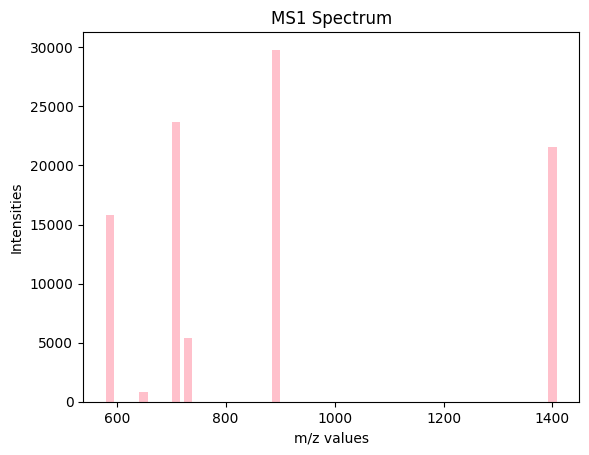

In [8]:
import proteosim as ps

ps.plot_spectrum(mz1_map.values(), random_count_range=(0, 30000), seed=42, title = "MS1 Spectrum")

In [9]:
import proteosim as ps

mypep = 'MATSR'
frags = ps.fragment_peptide(mypep)
frags

['M', 'MA', 'MAT', 'MATS', 'R', 'SR', 'TSR', 'ATSR']

In [10]:
import proteosim as ps

mass_map_ms2 = ps.calculate_mol_mass_collection(frags, ps.amino_acid_mass_dalton)
mass_map_ms2

{'M': 131.19,
 'MA': 202.27,
 'MAT': 303.38,
 'MATS': 390.46,
 'R': 156.19,
 'SR': 243.27,
 'TSR': 344.38,
 'ATSR': 415.46}

In [11]:
import proteosim as ps
mz2_map = ps.calculate_mz_collection(mass_map_ms2, charge = 1)
mz2_map

{'M': 132.197,
 'MA': 203.277,
 'MAT': 304.387,
 'MATS': 391.467,
 'R': 157.197,
 'SR': 244.277,
 'TSR': 345.387,
 'ATSR': 416.467}

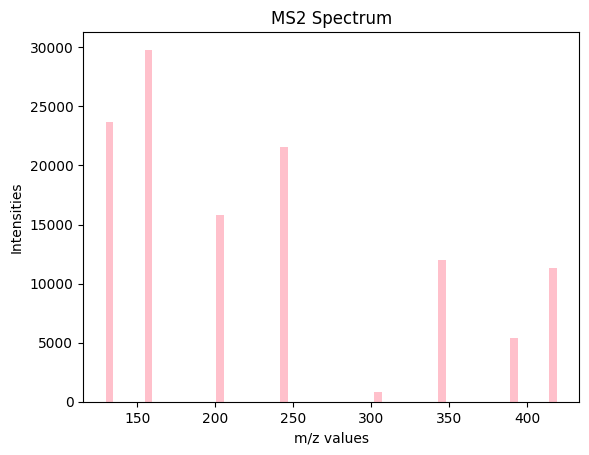

In [12]:
import proteosim as ps
ps.plot_spectrum(mz2_map.values(), title = "MS2 Spectrum", width = 5)